In [37]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['mathtext.fontset'] = 'cm'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
VBM = VBMicrolensing.VBMicrolensing() # Instance to VBMicroLensing
import MulensModel as mm

class MyBinaryLens(mm.BinaryLensPointSourceWM95Magnification):
    """Custom BinaryLens class potentially for modifications or extensions."""
    def __init__(self, q, s):
        # Initialize the parent MulensModel.BinaryLens
        # Calculates mass fractions m1, m2 from q

        self.s1 = s

        parameters = {'q': q, 's': s, 't_0': 0, 't_E': 1, 'u_0': 0.006, 'alpha': 0}
        model_params = mm.ModelParameters(parameters=parameters)

        traj = mm.Trajectory(times=0, parameters=model_params)

        super().__init__(trajectory=traj)

    def get_n_images(self, x, y):
        """
        Calculates the positions of images for a source at position (x, y).
        Relies on the _verify_polynomial_roots method from the parent class.
        """
        # Shift accounts for the coordinate system center (usually barycenter)
        # The length of the list of roots corresponds to the number of images
        self._get_1_magnification(x, y, separation=self.s1)

        return self._verify_polynomial_roots()

In [39]:
alpha1 = 0

In [42]:
s1_str = '1/0.2'
s1 = eval(s1_str)

q1 = 1e-3

binary_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
])

# Rotation matrix for first planet
first_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
    [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
])

# Binary offset
delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
print(f'Binary offset: {delta1}')

other_offset = np.array([0, 0])
print(f'Other offset: {other_offset}')

# Calculating center of mass of lenses
center_of_mass = np.average(binary_lens_attributes[:, :2], axis=0, weights=binary_lens_attributes[:, 2])
print(f'Center of mass: {center_of_mass}')

# Correcting binary lens attributes
binary_lens_attributes[:, :2] -= delta1 + other_offset

pixels = 2000
delta = 0.001

ang_width, thickness, (y_plus, y_minus), cusp_points = IRSC.IRSCaustics.ang_width_thickness_calculator(binary_lens_attributes, cm_offset='auto', cm_translation=delta1 - other_offset)

num_r, num_theta = IRSC.IRSCaustics.num_ray_calculator(pixels, ang_width, delta, y_plus, y_minus)

diff_y_plus = y_plus
diff_y_minus = y_minus
diff_thickness = diff_y_plus + diff_y_minus

print(f'Angular width: {ang_width}, Thickness: {diff_thickness}')
print(f'y_plus: {diff_y_plus}, y_minus: {diff_y_minus}')
print(f'Number of rays in r: {num_r}, Number of rays in theta: {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

binary_lens_parameters = {
    'pixels': 1000,
    'ang_width': 4 * ang_width,
    'thickness': diff_thickness,
    'y_plus': diff_y_plus,
    'y_minus': diff_y_minus,
    'lens_att': binary_lens_attributes.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim = IRSC.IRSCaustics(annulus_param_dict=binary_lens_parameters)
magnifications = sim.series_calculate(cm_offset='auto')

Binary offset: [0.00019212 0.        ]
Other offset: [0 0]
Center of mass: [0.004995 0.      ]
Angular width: 0.0004815376930761557, Thickness: 0.00037454842498807484
y_plus: 1.0001872917483092, y_minus: -0.9998127433233212
Number of rays in r: 8141508, Number of rays in theta: 2035377
Total number of rays: 1.657e+13


100%|██████████| 500/500 [00:04<00:00, 119.59it/s]

---------------------
Total time: 4.189 seconds


Plotting magnification map: 0.03 seconds
Cusp point 0: [-5.32266878e-05  0.00000000e+00]
Cusp point 1: [0.00012038 0.        ]
Cusp point 2: [0.00000000e+00 8.22172932e-05]
Cusp point 3: [ 0.00000000e+00 -8.22172932e-05]


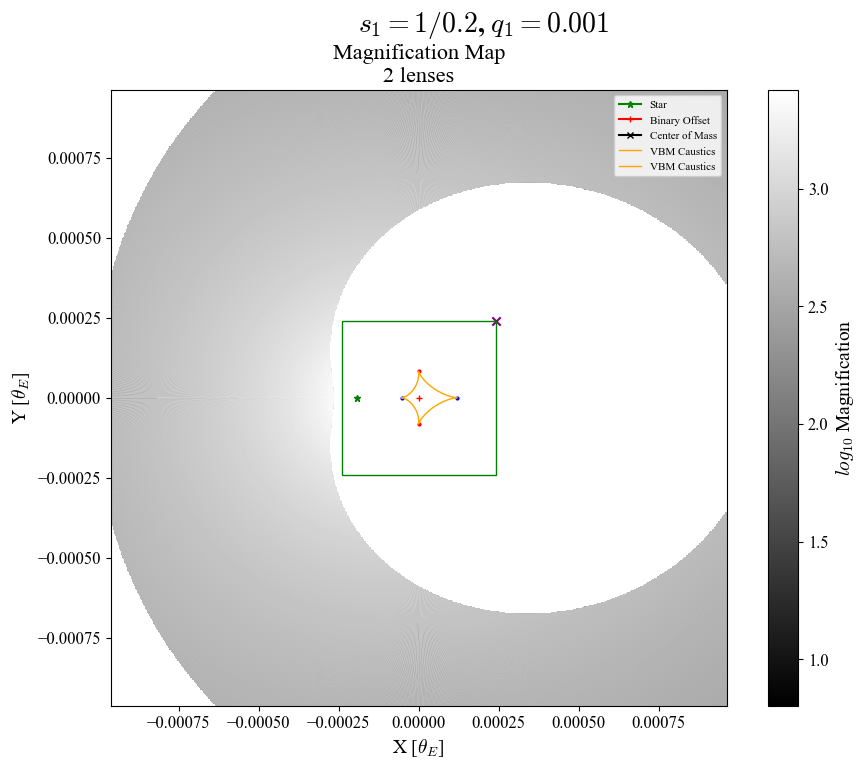

In [47]:
sim.plot()

for i, points in enumerate(cusp_points[0]):
    print(f'Cusp point {i}: {points}')
    if i < 2:
        sim.ax_c.plot(*(points), 'bo', markersize=2)
    else:
        sim.ax_c.plot(*(points), 'ro', markersize=2)

map_patch = patches.Rectangle(
    xy=(-ang_width/2, -ang_width/2),
    width=ang_width,
    height=ang_width,
    linewidth=1,
    edgecolor='green',
    facecolor='none'
)

sim.ax_c.plot(sim.lens_att[0, 0], sim.lens_att[0, 1], color='g', marker='*', markersize=5, label='Star')

sim.ax_c.plot(*(delta1 - delta1 - other_offset), color='r', marker='+', markersize=5, label='Binary Offset')
sim.ax_c.plot(*(center_of_mass - delta1 - other_offset), color='k', marker='x', markersize=5, label='Center of Mass')

ring = patches.Circle((0, 0), 1, fill=False, edgecolor='red', linestyle='--', linewidth=1)

sim.ax_c.set_aspect('equal')

new_ang_width = 2 * ang_width

sim.ax_c.set_xlim(-new_ang_width, new_ang_width)
sim.ax_c.set_ylim(-new_ang_width, new_ang_width)


sim.ax_c.scatter(ang_width / 2, ang_width / 2, color='purple', marker='x')

# VBM.SetLensGeometry(sim.lens_att.flatten().tolist())
caustics = VBM.Caustics(s1, q1)
# print(caustics)

for caustic in caustics:
    sim.ax_c.plot(caustic[0] + center_of_mass[0] - delta1[0], caustic[1] + center_of_mass[1] - delta1[1], 'orange', linewidth=1, label='VBM Caustics')

sim.ax_c.add_patch(map_patch)
sim.ax_c.add_patch(ring)
sim.fig_c.suptitle(f'$s_1 = {s1_str}$, $q_1 = {q1}$')
sim.ax_c.legend(loc='upper right')

plt.show()

In [27]:
s1_str = '1.4'
s1 = eval(s1_str)

q1 = 0.01

binary_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
])

# Rotation matrix for first planet
first_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
    [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
])

# Binary offset
delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
delta1 = np.array([0, 0])
print(f'Binary offset: {delta1}')

other_offset = np.array([0, 0])
print(f'Other offset: {other_offset}')

# Calculating center of mass of lenses
center_of_mass = np.average(binary_lens_attributes[:, :2], axis=0, weights=binary_lens_attributes[:, 2])
print(f'Center of mass: {center_of_mass}')

# Correcting binary lens attributes
binary_lens_attributes[:, :2] -= delta1 + other_offset

pixels = 2000
delta = 0.001

ang_width, thickness, (y_plus, y_minus), cusp_points = IRSC.IRSCaustics.ang_width_thickness_calculator(binary_lens_attributes, cm_offset='auto', cm_translation=delta1 - other_offset)

num_r, num_theta = IRSC.IRSCaustics.num_ray_calculator(pixels, ang_width, delta, y_plus, y_minus)

diff_y_plus = y_plus
diff_y_minus = y_minus
diff_thickness = diff_y_plus + diff_y_minus

print(f'Angular width: {ang_width}, Thickness: {diff_thickness}')
print(f'y_plus: {diff_y_plus}, y_minus: {diff_y_minus}')
print(f'Number of rays in r: {num_r}, Number of rays in theta: {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

binary_lens_parameters = {
    'pixels': 1000,
    'ang_width': 4 * ang_width,
    'thickness': diff_thickness,
    'y_plus': diff_y_plus,
    'y_minus': diff_y_minus,
    'lens_att': binary_lens_attributes.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim = IRSC.IRSCaustics(annulus_param_dict=binary_lens_parameters)
magnifications = sim.series_calculate(cm_offset='auto')

Binary offset: [0 0]
Other offset: [0 0]
Center of mass: [0.01386139 0.        ]
Angular width: 0.3500000000000001, Thickness: 0.27223611075682097
y_plus: 1.1453395994409616, y_minus: -0.8731034886841407
Number of rays in r: 8048132, Number of rays in theta: 2012033
Total number of rays: 1.619e+13


100%|██████████| 500/500 [00:02<00:00, 173.56it/s]

---------------------
Total time: 2.89 seconds



/Users/saividyud/Documents/GitHub/NBLens/tests/../IRSMicroLensing/IRSCaustics.py:685: RuntimeWarning: divide by zero encountered in log10
  self.magnifications_log = np.log10(self.magnifications)


Plotting magnification map: 0.018 seconds
Cusp point 0: [0.00243056 0.        ]
Cusp point 1: [0.0875 0.    ]
Cusp point 2: [0.         0.01711266]
Cusp point 3: [ 0.         -0.01711266]


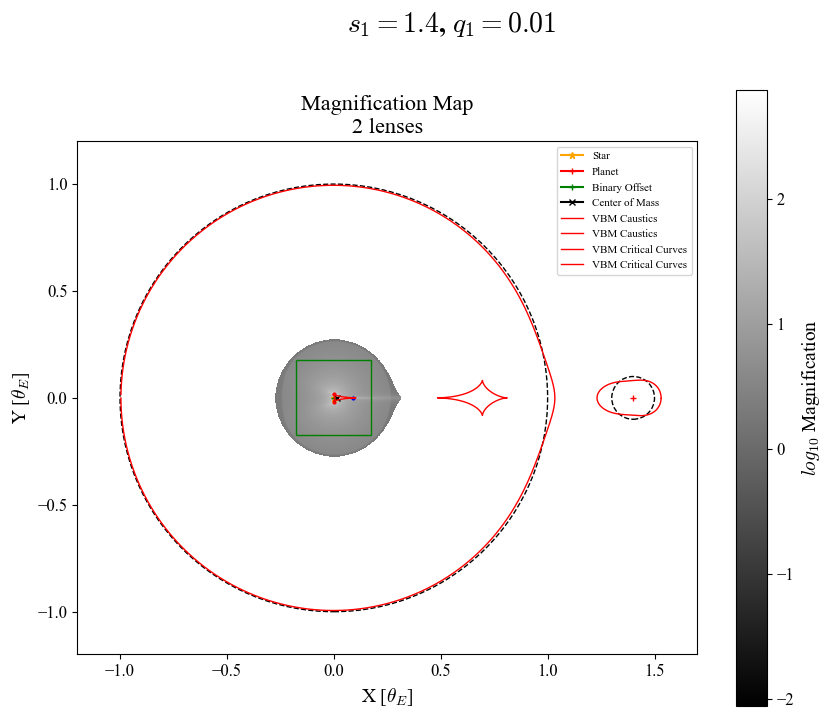

In [28]:
sim.plot()

for i, points in enumerate(cusp_points[0]):
    print(f'Cusp point {i}: {points}')
    if i < 2:
        sim.ax_c.plot(*(points), 'bo', markersize=2)
    else:
        sim.ax_c.plot(*(points), 'ro', markersize=2)

map_patch = patches.Rectangle(
    xy=(-ang_width/2, -ang_width/2),
    width=ang_width,
    height=ang_width,
    linewidth=1,
    edgecolor='green',
    facecolor='none'
)

sim.ax_c.plot(sim.lens_att[0, 0], sim.lens_att[0, 1], color='orange', marker='*', markersize=5, label='Star')
sim.ax_c.plot(sim.lens_att[1, 0], sim.lens_att[1, 1], color='red', marker='+', markersize=5, label='Planet')

sim.ax_c.plot(*(delta1 - delta1 - other_offset), color='green', marker='+', markersize=5, label='Binary Offset')
sim.ax_c.plot(*(center_of_mass - delta1 - other_offset), color='k', marker='x', markersize=5, label='Center of Mass')

ring = patches.Circle((0, 0), 1, fill=False, edgecolor='black', linestyle='--', linewidth=1)
small_ring = patches.Circle((sim.lens_att[1, 0], sim.lens_att[1, 1]), 0.1, fill=False, edgecolor='black', linestyle='--', linewidth=1)

sim.ax_c.set_aspect('equal')

new_ang_width = 1 * ang_width

# sim.ax_c.set_xlim(-new_ang_width, new_ang_width)
# sim.ax_c.set_ylim(-new_ang_width, new_ang_width)
sim.ax_c.set_xlim(-1.2, 1.7)
sim.ax_c.set_ylim(-1.2, 1.2)

# VBM.SetLensGeometry(sim.lens_att.flatten().tolist())
caustics = VBM.Caustics(s1, q1)
criticalcurve = VBM.Criticalcurves(s1, q1)
# print(caustics)

for caustic in caustics:
    sim.ax_c.plot(caustic[0] + center_of_mass[0] - delta1[0], caustic[1] + center_of_mass[1] - delta1[1], 'red', linewidth=1, label='VBM Caustics')

for curve in criticalcurve:
    sim.ax_c.plot(curve[0] + center_of_mass[0] - delta1[0], curve[1] + center_of_mass[1] - delta1[1], 'red', linewidth=1, label='VBM Critical Curves')

sim.ax_c.add_patch(map_patch)
sim.ax_c.add_patch(ring)
sim.ax_c.add_patch(small_ring)
sim.fig_c.suptitle(f'$s_1 = {s1_str}$, $q_1 = {q1}$')
sim.ax_c.legend(loc='upper right')
sim.ax_c.set_aspect('equal')

plt.show()

### Creating a circle that is just larger than the central caustic for s = 2 and q = 1e-3

In [319]:
r = 1.1 * ang_width/(np.sqrt(2))
thetas = np.linspace(0, 2 * np.pi, 1000, endpoint=False)
x_s = r * np.cos(thetas)
y_s = r * np.sin(thetas)

x_i = []
y_i = []

print(q1, s1)
model = MyBinaryLens(q1, s1)

# The source positions are defined with respect to the binary offset. It must be changed to be with respect to the center of mass.

for i, source_pos in enumerate(zip(x_s, y_s)):
    image_pos = model.get_n_images(source_pos[0] + delta1[0] - center_of_mass[0], source_pos[1] + delta1[1] - center_of_mass[1])

    for j, img in enumerate(image_pos):
        x_i.append(img.real)
        y_i.append(img.imag)

x_i = np.array(x_i)
y_i = np.array(y_i)

0.001 5


Plotting magnification map: 0.231 seconds
Cusp point 0: [0.00013889 0.        ]
Cusp point 1: [0.0003125 0.       ]
Cusp point 2: [0.00000000e+00 8.22172932e-05]
Cusp point 3: [ 0.00000000e+00 -8.22172932e-05]


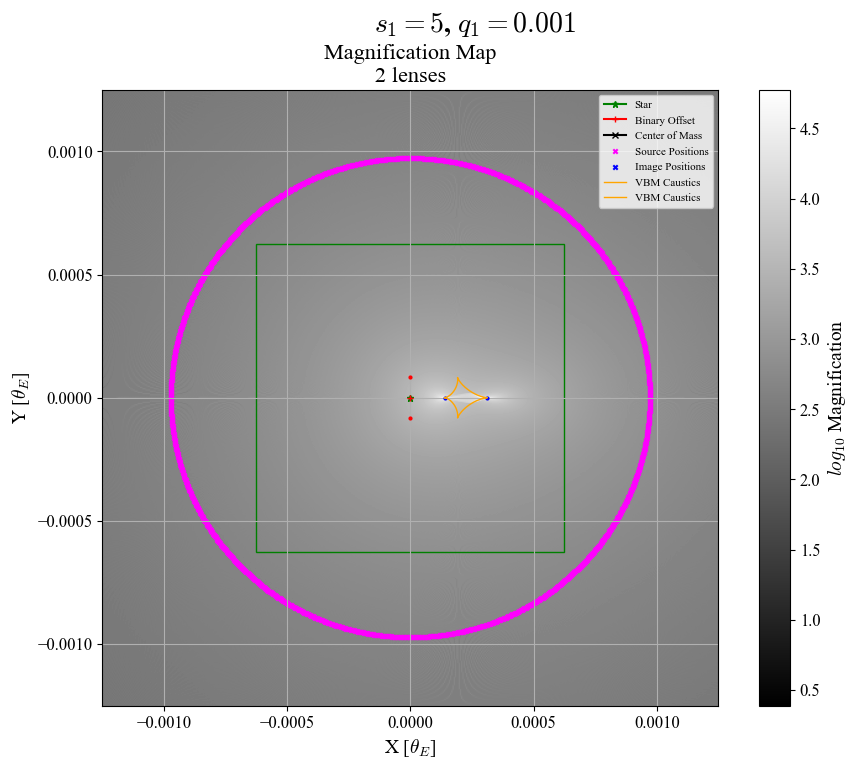

In [320]:
sim.plot()

for i, points in enumerate(cusp_points[0]):
    print(f'Cusp point {i}: {points}')
    if i < 2:
        sim.ax_c.plot(*(points), 'bo', markersize=2)
    else:
        sim.ax_c.plot(*(points), 'ro', markersize=2)

map_patch = patches.Rectangle(
    xy=(-ang_width/2, -ang_width/2),
    width=ang_width,
    height=ang_width,
    linewidth=1,
    edgecolor='green',
    facecolor='none'
)

sim.ax_c.plot(sim.lens_att[0, 0], sim.lens_att[0, 1], color='g', marker='*', markersize=5, label='Star')

sim.ax_c.plot(*(delta1 - delta1 - other_offset), color='r', marker='+', markersize=5, label='Binary Offset')
sim.ax_c.plot(*(center_of_mass - delta1 - other_offset), color='k', marker='x', markersize=5, label='Center of Mass')

ring = patches.Circle((0, 0), 1, fill=False, edgecolor='red', linestyle='--', linewidth=1)

sim.ax_c.set_aspect('equal')

new_ang_width = 1 * ang_width
sim.ax_c.set_xlim(-new_ang_width, new_ang_width)
sim.ax_c.set_ylim(-new_ang_width, new_ang_width)

# planet_view_offset = 0.000001
# planet_view_center = s1 + 0.0006665
# sim.ax_c.set_xlim(planet_view_center - planet_view_offset, planet_view_center + planet_view_offset)
# sim.ax_c.set_ylim(-planet_view_offset, planet_view_offset)

sim.ax_c.scatter(x_s, y_s, color='magenta', marker='x', s=10, label='Source Positions')
sim.ax_c.scatter(x_i + s1, y_i, color='blue', marker='x', s=10, label='Image Positions')

caustics = VBM.Caustics(s1, q1)
for caustic in caustics:
    sim.ax_c.plot(caustic[0] + center_of_mass[0] - delta1[0], caustic[1] + center_of_mass[1] - delta1[1], 'orange', linewidth=1, label='VBM Caustics')

sim.ax_c.add_patch(map_patch)
sim.ax_c.add_patch(ring)
sim.fig_c.suptitle(f'$s_1 = {s1_str}$, $q_1 = {q1}$')
sim.ax_c.legend(loc='upper right')

sim.ax_c.grid(True)

plt.show()

In [321]:
def separate_circles(x, y, threshold=0.5):
    """
    Separates coordinates into two circles based on distance from (0, 0) and (2, 0).
    Returns: (x_big, y_big), (x_small, y_small)
    """
    x = np.asarray(x)
    y = np.asarray(y)
    # Distance from (0, 0)
    r0 = np.sqrt(x**2 + y**2)
    # Distance from (2, 0)
    r2 = np.sqrt((x - 2)**2 + y**2)
    # Assign to big circle if closer to (0, 0), else to small circle
    big_mask = r0 < 1.5
    x_big = x[big_mask]
    y_big = y[big_mask]
    x_small = x[~big_mask]
    y_small = y[~big_mask]
    return (x_big, y_big), (x_small, y_small)

In [322]:
(x_big, y_big), (x_small, y_small) = separate_circles(x_i + s1 - delta1[0], y_i, threshold=1)

x_big = np.array(x_big)
y_big = np.array(y_big)

x_small = np.array(x_small)
y_small = np.array(y_small)

Plotting magnification map: 0.022 seconds


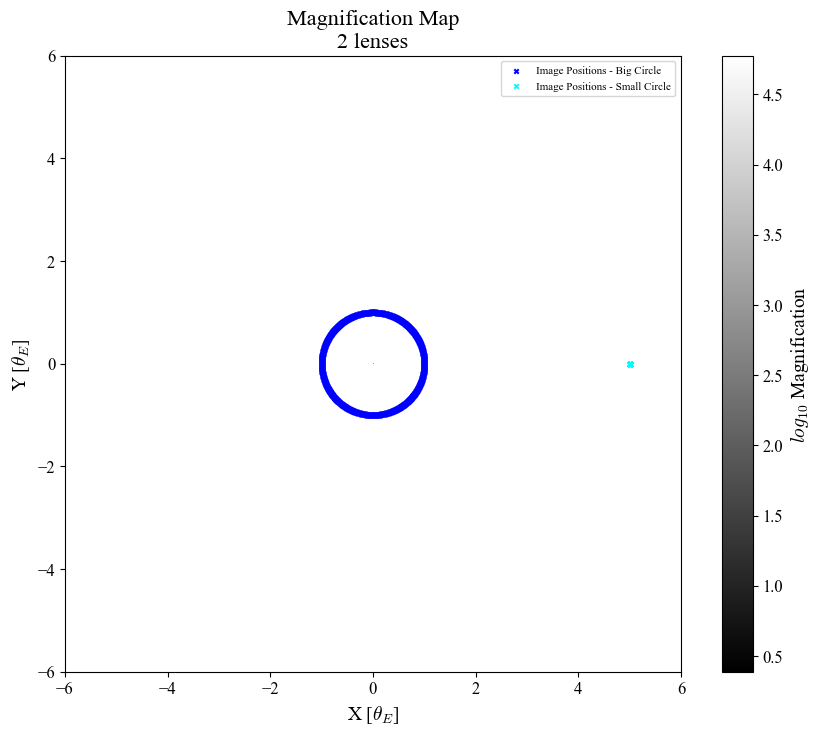

In [323]:
sim.plot()

sim.ax_c.scatter(x_big, y_big, color='blue', marker='x', s=10, label='Image Positions - Big Circle')
sim.ax_c.scatter(x_small, y_small, color='cyan', marker='x', s=10, label='Image Positions - Small Circle')

new_ang_width = 6

sim.ax_c.set_xlim(-new_ang_width, new_ang_width)
sim.ax_c.set_ylim(-new_ang_width, new_ang_width)

sim.ax_c.legend(loc='upper right')
plt.show()

In [324]:
print(np.mean(x_big), np.mean(y_big))

r_big = np.sqrt(x_big**2 + y_big**2)
theta_big = np.arctan2(y_big, x_big) * 180 / np.pi

print(np.mean(r_big))

-9.989558843487912e-05 -3.588240815588506e-16
0.9995004992287677


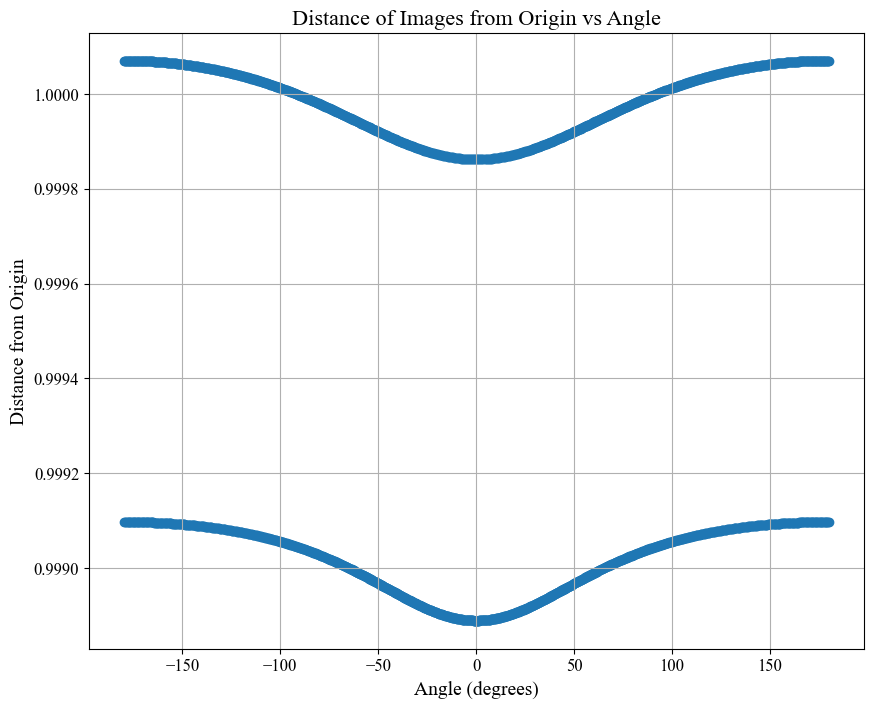

In [325]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

ax.set_title('Distance of Images from Origin vs Angle')

ax.scatter(theta_big, r_big)

ax.set_xlabel('Angle (degrees)')
ax.set_ylabel('Distance from Origin')
ax.grid(True)

plt.show()

In [231]:
print(1 + 1.5*q1**(1/3))
print(1 - 0.75*q1**(1/3))

1.15
0.925
